# 05. Non-linear models

**Context** (from NB04)
- Ridge cuts R90 search area by roughly half from 12h onward; the cut does not grow with horizon. Ridge R90 still reaches about **817 km** at 72h.
- Gain is uneven: baseline keeps more low-error mass (lower R50); Ridge is better on mid-to-upper percentiles and worse in the extreme tail. A working hypothesis is that below-median baseline residuals are mostly straight tracks, where constant-velocity extrapolation is exact by construction.
- Extra lags beyond 6, a longer lookback, or stronger regularization do not move the needle. The limit looks informational (what a global linear map can express).

**Objective**
- Test LGBM on the same base features (faster ROI than engineering features for a linear model).
- Check lag count and lookback.
- Run a small tuning probe.

**Outcome**
- LGBM has the lowest MAE at **every** horizon and controls the tail (R90 search-area cut about **64% at 12h**, **79% at 72h**).
- The baseline keeps the lower R50 on easy tracks.
- Tuning is marginal (~**2.4%**).
- Ridge dropped; feature engineering next (NB06).


## Contents

1. Setup
2. Reused functions
3. LGBM vs baseline across horizons
4. Lookback spot check (3h)
5. Hyperparameter check
6. Results and interpretation


## 1. Setup


In [1]:

import gc
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_PROCESSED
from vessel_tracker.preprocessing import vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

# --- Load cleaned + resampled dataset (NB02) ---
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df = pd.read_parquet(processed_path)
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

#downcasting to save RAM
float_cols = ["LAT", "LON", "SOG", "Heading", "Length", "Width", "Draft"]
df[float_cols] = df[float_cols].astype("float32")
df["MMSI"] = df["MMSI"].astype("int32")

print(f"Loaded: {len(df):,} rows, {df['MMSI'].nunique():,} vessels")

# --- Replay the split (same seed → same partition as NB02) ---
df_train, df_val, df_test, *_ = vessel_train_test_split(df)
print(f"Train: {df_train['MMSI'].nunique():,} vessels | "
      f"Val: {df_val['MMSI'].nunique():,} | Test: {df_test['MMSI'].nunique():,}")
df_trainval = pd.concat([df_train, df_val], axis=0)

Loaded: 3,661,057 rows, 2,173 vessels
Train: 1,521 vessels | Val: 326 | Test: 326


## 2. Reused functions


In [2]:
def create_lag_features(df, nb_lags: int, lookback_minutes: int):
    """
    Add evenly spaced lag features (LAT_lag_i, LON_lag_i) for each vessel.

    Parameters:
    -----------
    df : DataFrame
        Must contain MMSI, LAT, LON.
    nb_lags : int
        Number of lag columns to generate (2 to available_lags).
    lookback_minutes : int
        Lookback duration in minutes, converted to steps via settings.resample_interval_min.

    Returns:
    --------
    DataFrame
        Same rows minus warm-up rows without a full lookback. LAT/LON are replaced
        by LAT_lag_i / LON_lag_i columns (lag 0 is the current position).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    available_lags = lookback_steps + 1
    #check if there are enough time steps for the number of lags required
    if not (2 <= nb_lags <= available_lags):
        raise ValueError(f"nb_of_lags={nb_lags} does not fit lookback_steps={lookback_steps}: "
            f"expected 1..{available_lags}.")

    #generate lags evenly spaced

    lags = np.unique(np.linspace(0, lookback_steps, nb_lags).round().astype(int))
    if len(lags) != nb_lags:
        raise ValueError(
            f"rounding over a {lookback_steps}-step window reduced the number of lags"
            f"number of lags asked : {nb_lags} number of lags obtained: {len(lags)}"

        )


    vessels  = df.groupby("MMSI")

    lag_col = {f"{coord}_lag_{lag}": vessels[coord].shift(lag)
               for lag in lags
               for coord in ("LAT", "LON")
               }
    df = df.assign(**lag_col).drop(columns= ["LAT", "LON"]).dropna(axis= 0)
    return df


In [3]:
def create_heading_features(df):
    """
    Cyclical encoding of compass heading (degrees to sin/cos).

    Parameters:
    -----------
    df : DataFrame
        Must contain Heading (degrees, 0-360).

    Returns:
    --------
    DataFrame
        Same df with Heading replaced by Heading_sin and Heading_cos.
    """
    heading_rad = np.radians(df["Heading"])
    df = df.assign(
        Heading_sin=np.sin(heading_rad),
        Heading_cos=np.cos(heading_rad),
    )
    
    df = df.drop(columns= ["Heading"])
    return df


In [4]:
def create_target(df: pd.DataFrame, horizon_grid_minutes: list[int]):

    """
    Build a long-format DataFrame of velocity targets for a list of prediction horizons.

    Parameters:
    -----------
    df : DataFrame
        Must already contain lag features, including LAT_lag_0 and LON_lag_0
        (current position) and columns MMSI, BaseDateTime.
    horizon_grid_minutes : list[int]
        Requested prediction horizons in minutes. Rounded to the nearest multiple
        of settings.resample_interval_min, deduplicated, and horizons rounding to
        0 are dropped. Raises ValueError if none remain.

    Returns:
    --------
    DataFrame
        One row per (source row, usable horizon). Added columns:
        vx, vy (deg/min velocity targets), h (effective horizon in minutes).
        Rows without a future position (end of track) are dropped.
    """
    horizons = np.asarray(horizon_grid_minutes)
    h_steps = np.unique(np.round(horizons / settings.resample_interval_min)).astype(int)
    h_steps = h_steps[h_steps > 0]
    if len(h_steps) == 0:
        raise ValueError("no prediction horizon > 0")

    required_cols = ["MMSI", "BaseDateTime", "LAT_lag_0", "LON_lag_0"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(drop=True)

    lat0 = df["LAT_lag_0"].to_numpy()
    lon0 = df["LON_lag_0"].to_numpy()
    grp = df.groupby("MMSI")

    target_parts = []
    for h_step in h_steps:
        lat_fut = grp["LAT_lag_0"].shift(-h_step).to_numpy()
        lon_fut = grp["LON_lag_0"].shift(-h_step).to_numpy()
        dt = int(h_step * settings.resample_interval_min) #cast as int to avoid upcast to float64
        target_parts.append(pd.DataFrame({
            "row_id": np.arange(len(df), dtype=np.int64),
            "vx": (lon_fut - lon0) / dt,
            "vy": (lat_fut - lat0) / dt,
            "h": np.int16(dt),
        }))

    targets = pd.concat(target_parts, ignore_index=True).dropna(subset=["vx", "vy"])

    df_out = df.iloc[targets["row_id"].to_numpy()].reset_index(drop=True)
    df_out["vx"] = targets["vx"].to_numpy()
    df_out["vy"] = targets["vy"].to_numpy()
    df_out["h"] = targets["h"].to_numpy()
    return df_out


In [5]:
def evaluate_baseline_fold(X_val, lookback_minutes):
    """
    Compute baseline (constant-velocity extrapolation) predicted velocity for one fold.

    Extrapolates from lag_0 (current position) and lag_lookback_steps (oldest
    lookback position), expressed as a velocity in deg/minute (same unit as vx, vy).

    Parameters:
    -----------
    X_val : DataFrame
        Validation fold features. Must contain LAT_lag_0, LON_lag_0,
        LAT_lag_{lookback_steps}, LON_lag_{lookback_steps}.
    lookback_minutes : int
        Lookback duration in minutes.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), extrapolated longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), extrapolated latitude velocity (deg/min)
        inference_time_s : float, wall-clock seconds for the extrapolation computation
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]
    missing = [col for col in required_cols if col not in X_val.columns]
    if missing:
        raise ValueError(f"Missing required columns in X_val: {missing}")

    t0 = time.perf_counter()

    LAT_now = X_val["LAT_lag_0"]
    LON_now = X_val["LON_lag_0"]
    LAT_old = X_val[f"LAT_lag_{lookback_steps}"]
    LON_old = X_val[f"LON_lag_{lookback_steps}"]

    vy_pred = (LAT_now - LAT_old) / lookback_minutes
    vx_pred = (LON_now - LON_old) / lookback_minutes

    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": vx_pred.to_numpy(),
        "vy_pred": vy_pred.to_numpy(),
        "inference_time_s": inference_time_s,
    }


In [6]:
def evaluate_model_fold(X_train, y_train, X_val, estimator):
    """
    Fit estimator on one training fold, predict velocity (vx, vy) on the validation fold.

    Parameters:
    -----------
    X_train, y_train : DataFrame
        Training fold features and targets, y_train columns [vx, vy].
    X_val : DataFrame
        Validation fold features.
    estimator : sklearn estimator
        Base estimator, wrapped in MultiOutputRegressor internally.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), predicted longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), predicted latitude velocity (deg/min)
        fit_time_s : float, wall-clock seconds for model.fit
        inference_time_s : float, wall-clock seconds for model.predict
    """
    model = MultiOutputRegressor(estimator=estimator)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_val)
    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": y_pred[:, 0],
        "vy_pred": y_pred[:, 1],
        "fit_time_s": fit_time_s,
        "inference_time_s": inference_time_s,
    }

In [7]:
def run_crossval(
    df,
    model,
    model_name: str,
    lookback_minutes,
    n_splits: int = 5,
    random_state: int = None,
    with_baseline: bool = True,
):
    """
    Run GroupKFold cross-validation for a single model (and optionally the baseline)
    on a long-format dataframe covering one or several horizons h. Reconstructs
    positions and the per-row haversine error (error_km) once, here.

    Parameters:
    -----------
    df : DataFrame
        Long-format frame from create_target (+ create_lag_features + create_heading_features).
        Must contain MMSI, BaseDateTime, vx, vy, h, Heading_sin, Heading_cos.
    model : sklearn estimator
        Base estimator for the candidate model (wrapped in MultiOutputRegressor internally).
    model_name : str
        Name used to tag the model's rows in oof_df (e.g. "Ridge").
    lookback_minutes : int
        Lookback duration in minutes, forwarded to evaluate_baseline_fold.
    n_splits : int
        Number of GroupKFold splits (grouped on MMSI).
    random_state : int, optional
        Shuffle seed; defaults to settings.random_seed.
    with_baseline : bool
        If True, also evaluate the constant-velocity baseline on every fold.

    Returns:
    --------
    oof_df : DataFrame
        One row per (out-of-fold observation, predictor). Columns:
        model_name, MMSI, h, LAT_lag_0, LON_lag_0, vx_true, vy_true, vx_pred, vy_pred,
        error_km.
    timings : DataFrame
        One row per candidate. Columns: model_name, fit_time_s, inference_time_s
        (mean over folds). Not saved downstream in this notebook.
    """
    
    #sanity check: check if feature and target are present
    required_cols = ["MMSI", "BaseDateTime", "vx", "vy", "h", "Heading_sin", "Heading_cos"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if random_state is None:
        random_state = settings.random_seed

    # shuffle rows to break MMSI ordering; reset_index keeps val_idx (from gkf.split)
    # positionally aligned with the numpy arrays returned by the fold functions
    df = df.copy().sample(frac=1, random_state=random_state).reset_index(drop=True)

    feature_cols = [col for col in df.columns if col.startswith(("LAT_lag", "LON_lag"))]
    feature_cols += ["SOG", "Heading_sin", "Heading_cos", "Length", "Width", "Draft", "h"]

    X = df[feature_cols]
    y = df[["vx", "vy"]]
    groups = df["MMSI"]

    # group split to avoid vessel-level leakage
    gkf = GroupKFold(n_splits=n_splits)

    candidate_names = [model_name] + (["Baseline"] if with_baseline else [])
    
    # fold wall-clock times (returned but not persisted in this notebook)
    fold_timings = {
        name: {"fit_time": [], "inference_time": []}
        for name in candidate_names
    }
    
    oof_parts = [] #for storage of results from the val sets of each fold

    #crossval 
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        # keep this info from the val set to the output (will be useful for position calculation and stratified analysis)
        passthrough = df.iloc[val_idx][["MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx", "vy"]]
        passthrough = passthrough.rename(columns={"vx": "vx_true", "vy": "vy_true"})

        model_result = evaluate_model_fold(X_train, y_train, X_val, model)
        fold_timings[model_name]["fit_time"].append(model_result["fit_time_s"])
        fold_timings[model_name]["inference_time"].append(model_result["inference_time_s"])

        # store the results and predictions of the val set of THIS fold
        model_part = passthrough.copy()
        model_part["model_name"] = model_name
        model_part["vx_pred"] = model_result["vx_pred"] #vx_pred is an array, will align positionally, not by index
        model_part["vy_pred"] = model_result["vy_pred"]
        oof_parts.append(model_part)

        #add baseline prediction as well
        if with_baseline:
            baseline_result = evaluate_baseline_fold(X_val, lookback_minutes)
            fold_timings["Baseline"]["fit_time"].append(0.0)
            fold_timings["Baseline"]["inference_time"].append(baseline_result["inference_time_s"])

            baseline_part = passthrough.copy()
            baseline_part["model_name"] = "Baseline"
            baseline_part["vx_pred"] = baseline_result["vx_pred"]
            baseline_part["vy_pred"] = baseline_result["vy_pred"]
            oof_parts.append(baseline_part)

    # concat vertically the val set results from all folds
    oof_df = pd.concat(oof_parts, ignore_index=True)[
        ["model_name", "MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx_true", "vy_true", "vx_pred", "vy_pred"]
    ]

    # reconstruct positions and the haversine error once, here, so no other
    # function needs to touch position space or recompute error_km
    LON_pred = oof_df["LON_lag_0"] + oof_df["vx_pred"] * oof_df["h"]
    LAT_pred = oof_df["LAT_lag_0"] + oof_df["vy_pred"] * oof_df["h"]
    LON_true = oof_df["LON_lag_0"] + oof_df["vx_true"] * oof_df["h"]
    LAT_true = oof_df["LAT_lag_0"] + oof_df["vy_true"] * oof_df["h"]
    oof_df["error_km"] = haversine_distance(
        LAT_true.to_numpy(), LON_true.to_numpy(), LAT_pred.to_numpy(), LON_pred.to_numpy()
    )

    timings = pd.DataFrame([
        {
            "model_name": name,
            "fit_time_s": float(np.mean(fold_timings[name]["fit_time"])),
            "inference_time_s": float(np.mean(fold_timings[name]["inference_time"])),
        }
        for name in candidate_names
    ])

    return oof_df, timings


In [8]:
def compute_metrics(oof_df):
    """
    Aggregate the per-row haversine error (already computed by run_crossval) into
    per-(model_name, h) metrics.

    Parameters:
    -----------
    oof_df : DataFrame
        Output of run_crossval. Must contain model_name, h, error_km.

    Returns:
    --------
    DataFrame
        One row per (model_name, h). Columns:
        model_name, h, mae_mean, r50_km, r80_km, r90_km, r95_km.
    """
    rows = []

    # mae and R(h,p) must be calculated by horizon, so we need to groupby
    for (name, h), horizon_subset in oof_df.groupby(["model_name", "h"]):
        r50, r80, r90, r95 = np.percentile(horizon_subset["error_km"], [50, 80, 90, 95])
        rows.append({
            "model_name": name,
            "h": h,
            "mae_mean": float(horizon_subset["error_km"].mean()),
            "r50_km": float(r50),
            "r80_km": float(r80),
            "r90_km": float(r90),
            "r95_km": float(r95),
        })

    return pd.DataFrame(
        rows, columns=["model_name", "h", "mae_mean", "r50_km", "r80_km", "r90_km", "r95_km"]
    )

## 3. LGBM vs baseline across horizons

- **§3.0**: nb_lags spot check on `{2, 6, 72}` (reduced horizon grid).
- **§3.1+**: main evaluation at **`LAG_REF = 6`** only (same operating point as Ridge), lookback 12h, full horizon grid.


In [9]:
lgbm_model = LGBMRegressor(verbose=-1)

### 3.0 nb_lags spot check

Cached lag-sweep figure found, skipping crossval (set FORCE_RECOMPUTE=True to rerun).


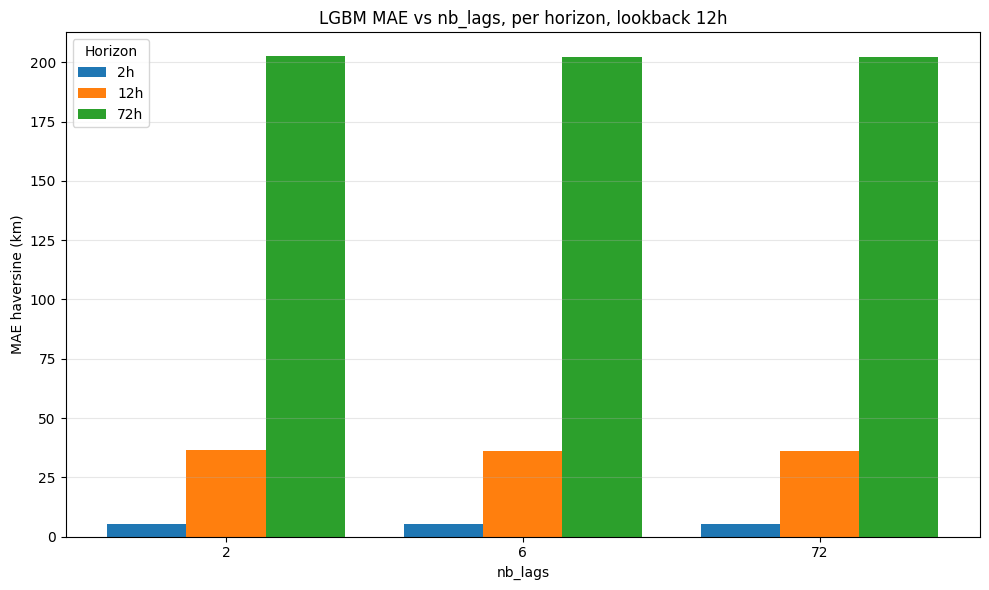

In [10]:
# 3.0: internal exploration: how many lags actually help?
# reduced horizon grid, no baseline. MAE vs nb_lags only.
# Cache key = saved figure (no numeric summary persisted).

lookback = 12
horizon_grid_hours_probe = [2, 12, 72]
candidates_lag = [2, 6, 72]
FORCE_RECOMPUTE = False  # set True to rerun the sweep even if the figure exists

horizon_grid_minutes_probe = [h * 60 for h in horizon_grid_hours_probe]
viz_path = Path("../visualizations/lag_sweep_lgbm.png")

if not FORCE_RECOMPUTE and viz_path.exists():
    print("Cached lag-sweep figure found, skipping crossval (set FORCE_RECOMPUTE=True to rerun).")
    from IPython.display import Image, display
    display(Image(filename=str(viz_path)))
else:
    lag_sweep_parts = []

    for lag in candidates_lag:
        print(f"testing lag {lag}")
        d = create_lag_features(df=df_trainval, nb_lags=lag, lookback_minutes=lookback * 60)
        d = create_heading_features(df=d)
        d = create_target(df=d, horizon_grid_minutes=horizon_grid_minutes_probe)

        oof_df, _ = run_crossval(
            df=d, model=lgbm_model, model_name="LGBM",
            lookback_minutes=lookback * 60, with_baseline=False,
        )

        summary_lag = compute_metrics(oof_df)
        summary_lag["nb_lags"] = lag
        lag_sweep_parts.append(summary_lag)

    lag_sweep_summary = pd.concat(lag_sweep_parts, ignore_index=True)
    lag_sweep_summary["horizon_hours"] = lag_sweep_summary["h"] / 60

    # plot: MAE vs nb_lags at each probe horizon
    probe_horizons = sorted(lag_sweep_summary["horizon_hours"].unique())
    lags = sorted(lag_sweep_summary["nb_lags"].unique())

    x = np.arange(len(lags))
    width = 0.8 / len(probe_horizons)

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, h in enumerate(probe_horizons):
        sub = (lag_sweep_summary[lag_sweep_summary["horizon_hours"] == h]
               .set_index("nb_lags").reindex(lags))
        ax.bar(x + i * width, sub["mae_mean"], width, label=f"{h:g}h")

    ax.set_xticks(x + width * (len(probe_horizons) - 1) / 2)
    ax.set_xticklabels(lags)
    ax.set_xlabel("nb_lags")
    ax.set_ylabel("MAE haversine (km)")
    ax.set_title("LGBM MAE vs nb_lags, per horizon, lookback 12h")
    ax.legend(title="Horizon")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    viz_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(viz_path, dpi=150, bbox_inches="tight")
    plt.show()

    del d, oof_df
    _ = gc.collect()


The number of lags has no marked effect on LGBM, at any of the three probe horizons. This mirrors the Ridge result, trajectory history beyond a handful of lags does not add usable signal. nb_lags is fixed at 6 downstream, the same setting used for Ridge, for a like-for-like comparison.


### 3.1 Crossval


In [11]:



lookback = 12
horizon_grid_hours = [2, 4, 6, 8, 10, 12, 24, 48, 72]
LAG_REF = 6  # retained nb_lags (from §3.0); used by graphs/tables below and 3h section
FORCE_RECOMPUTE = False  # set True to refit even if cached outputs exist

horizon_grid_minutes = [h * 60 for h in horizon_grid_hours]

out_dir = Path("outputs")
summary_path_12h = out_dir / "lgbm_summary_12h.csv"
oof_path_12h = out_dir / "lgbm_oof_12h.parquet"

if not FORCE_RECOMPUTE and summary_path_12h.exists() and oof_path_12h.exists():
    print("Cached 12h results found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_12h = pd.read_csv(summary_path_12h)
    oof_ref_12h = pd.read_parquet(oof_path_12h)
else:
    df_lag = create_lag_features(df=df_trainval, nb_lags=LAG_REF, lookback_minutes=lookback*60)
    df_lag = create_heading_features(df=df_lag)
    df_lag = create_target(df=df_lag, horizon_grid_minutes=horizon_grid_minutes)

    oof_ref_12h, _ = run_crossval(
        df=df_lag, model=lgbm_model, model_name="LGBM",
        lookback_minutes=lookback*60, with_baseline=True,
    )

    summary_12h = compute_metrics(oof_ref_12h)
    summary_12h["nb_lags"] = LAG_REF
    summary_12h["horizon_hours"] = summary_12h["h"] / 60


Cached 12h results found, loading from disk (set FORCE_RECOMPUTE=True to refit).


In [12]:
out_dir.mkdir(parents=True, exist_ok=True)
summary_12h.to_csv(summary_path_12h, index=False)
oof_ref_12h.to_parquet(oof_path_12h, index=False)


### 3.2 Clean up and plots


#### 3.2.1 MAE

MAE of LGBM against the baseline across horizons, at `LAG_REF` (6 lags).


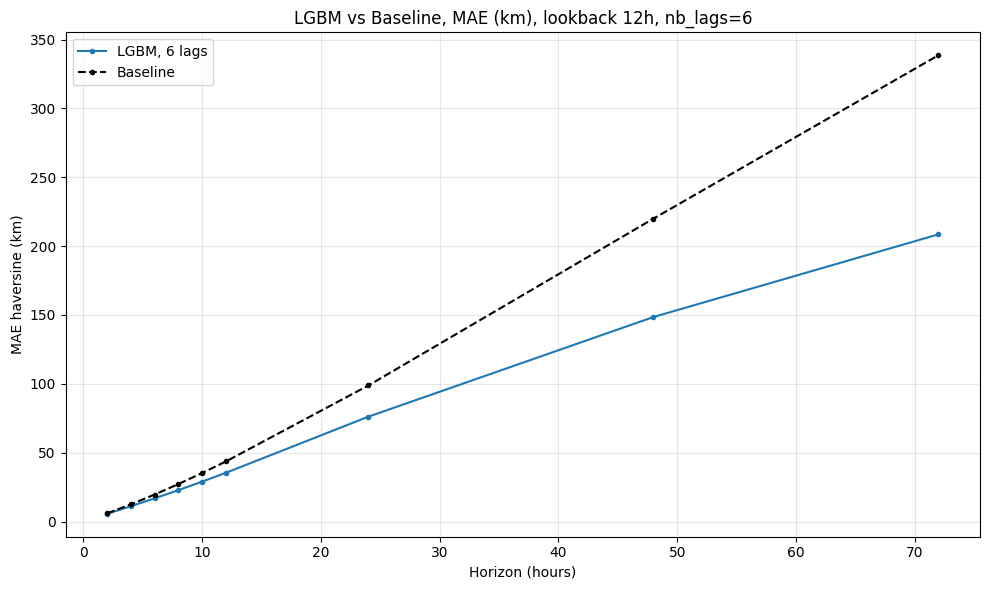

In [13]:
# --- Graph 1: MAE (km) vs horizon ---
fig, ax = plt.subplots(figsize=(10, 6))

lgbm_df = (
    summary_12h[(summary_12h["model_name"] == "LGBM") & (summary_12h["nb_lags"] == LAG_REF)]
    .sort_values("horizon_hours")
)
baseline_df = summary_12h[summary_12h["model_name"] == "Baseline"].sort_values("horizon_hours")

ax.plot(lgbm_df["horizon_hours"], lgbm_df["mae_mean"], marker="o", markersize=3,
        linestyle="-", label=f"LGBM, {LAG_REF} lags")
ax.plot(baseline_df["horizon_hours"], baseline_df["mae_mean"], marker="o", markersize=3,
        linestyle="--", color="black", label="Baseline")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title(f"LGBM vs Baseline, MAE (km), lookback 12h, nb_lags={LAG_REF}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


On km error (Haversine MAE) LGBM is better than baseline at every horizon, with an increasing effect over time. The longer the horizon, the more LGBM proves useful. 


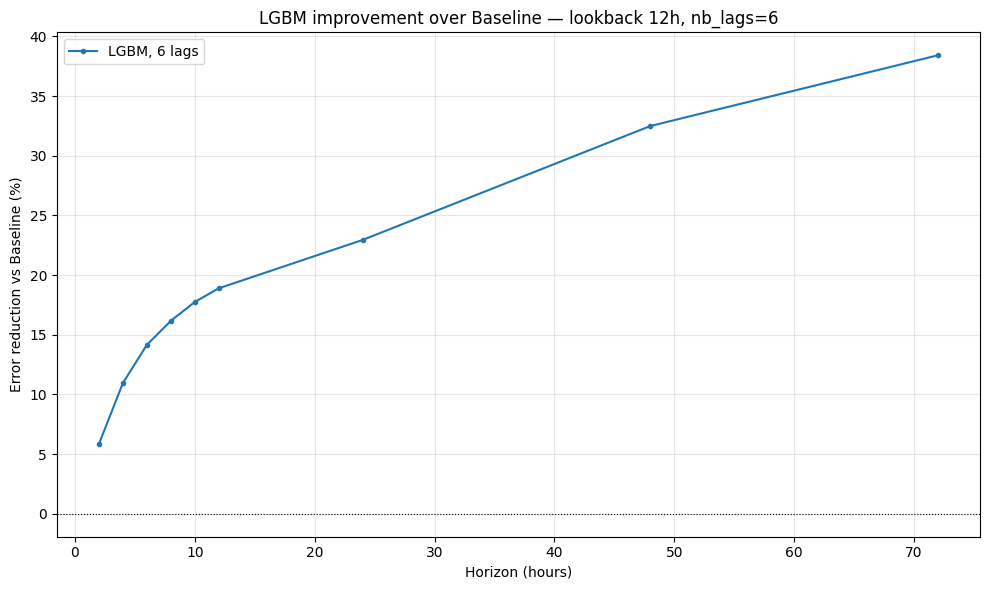

In [14]:
# --- Graph 2: improvement over Baseline (%) ---
baseline_lookup = baseline_df.set_index("horizon_hours")["mae_mean"]
mae_baseline = lgbm_df["horizon_hours"].map(baseline_lookup)
improvement_pct = (mae_baseline - lgbm_df["mae_mean"]) / mae_baseline * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lgbm_df["horizon_hours"], improvement_pct, marker="o", markersize=3,
        linestyle="-", label=f"LGBM, {LAG_REF} lags")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Error reduction vs Baseline (%)")
ax.set_title(f"LGBM improvement over Baseline — lookback 12h, nb_lags={LAG_REF}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 3.2.2 R(p,h)

The same runs read as an uncertainty radius. R50 is the median residual, R90 the tail.


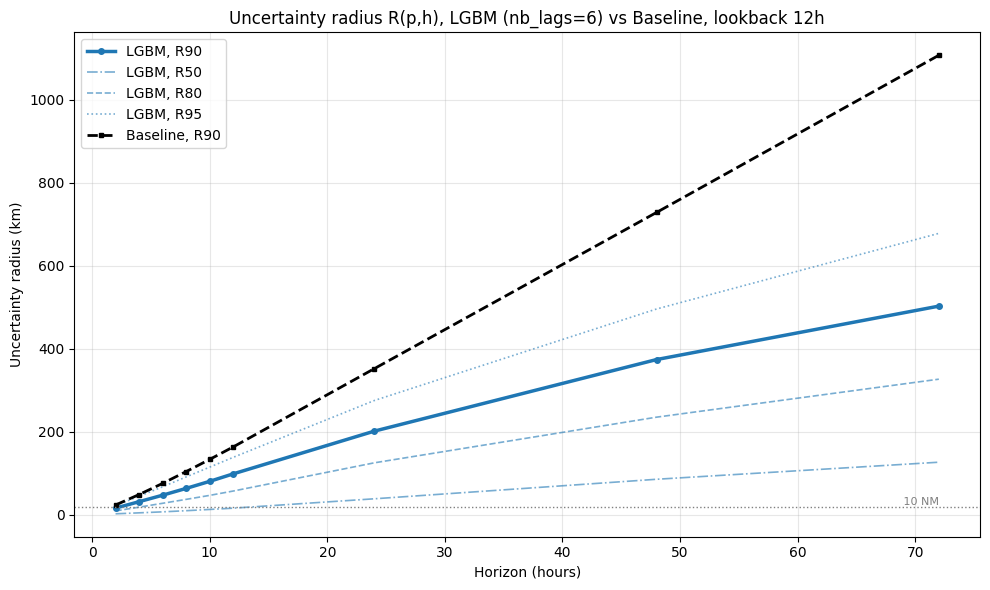

In [16]:
# --- Graph 3: uncertainty radius R(p,h), LGBM (nb_lags=6) vs Baseline ---
NM_TO_KM = 1.852

lgbm_r = summary_12h[
    (summary_12h["model_name"] == "LGBM") & (summary_12h["nb_lags"] == LAG_REF)
].sort_values("horizon_hours")

baseline_r = summary_12h[summary_12h["model_name"] == "Baseline"].sort_values("horizon_hours")

fig, ax = plt.subplots(figsize=(10, 6))

# LGBM, R90 bold; R50 / R80 / R95 lighter
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r90_km"], color="C0", linewidth=2.5,
        marker="o", markersize=4, label="LGBM, R90")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r50_km"], color="C0", linewidth=1.2,
        linestyle="-.", alpha=0.6, label="LGBM, R50")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r80_km"], color="C0", linewidth=1.2,
        linestyle="--", alpha=0.6, label="LGBM, R80")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r95_km"], color="C0", linewidth=1.2,
        linestyle=":", alpha=0.6, label="LGBM, R95")

# Baseline, R90 only, dashed black
ax.plot(baseline_r["horizon_hours"], baseline_r["r90_km"], color="black", linewidth=2,
        linestyle="--", marker="s", markersize=3, label="Baseline, R90")

# SAR reference line (10 NM)
ax.axhline(10 * NM_TO_KM, color="gray", linestyle=":", linewidth=1)
ax.text(lgbm_r["horizon_hours"].max(), 10 * NM_TO_KM, " 10 NM", va="bottom", ha="right", fontsize=8, color="gray")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title(f"Uncertainty radius R(p,h), LGBM (nb_lags={LAG_REF}) vs Baseline, lookback 12h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# Table: horizon × R50/R80/R90/R95 (km), LGBM (nb_lags=6) vs Baseline
radius_tbl = (
    summary_12h[
        (
            ((summary_12h["model_name"] == "LGBM") & (summary_12h["nb_lags"] == LAG_REF))
            | (summary_12h["model_name"] == "Baseline")
        )
    ]
    .pivot_table(
        index="horizon_hours",
        columns="model_name",
        values=["r50_km", "r80_km", "r90_km", "r95_km"],
        aggfunc="first",
    )
    .sort_index()
    .round(2)
)
# MultiIndex columns (radius, model), readable as-is
radius_tbl = radius_tbl.reindex(
    columns=pd.MultiIndex.from_product(
        [["r50_km", "r80_km", "r90_km", "r95_km"], ["Baseline", "LGBM"]]
    )
)
radius_tbl


r50_km           r80_km           r90_km           r95_km  \
              Baseline    LGBM Baseline    LGBM Baseline    LGBM Baseline   
horizon_hours                                                               
2.0               0.01    2.26    10.57    9.23    23.43   15.96    32.79   
4.0               0.01    4.55    23.59   18.24    48.64   31.43    66.24   
6.0               0.03    6.96    37.98   27.60    75.51   47.10   101.46   
8.0               0.05    9.72    53.75   37.03   103.96   63.47   137.89   
10.0              0.09   12.73    70.63   46.63   133.35   80.44   174.88   
12.0              0.14   15.83    88.57   57.10   163.40   98.50   212.79   
24.0              1.72   38.42   208.23  125.12   352.13  201.50   444.60   
48.0             40.24   85.48   465.16  235.19   728.72  374.04   910.45   
72.0             90.88  126.60   682.53  326.75  1107.55  502.85  1384.45   

                       
                 LGBM  
horizon_hours          
2.0             22.42  
4.0             44.36  
6.0             67.34  
8.0             91.09  
10.0           114.75  
12.0           138.32  
24.0           275.31  
48.0           495.94  
72.0           678.24

On R90, LGBM is below the baseline at every horizon, and the gap grows with h (23→16 km at 2h, 163→99 at 12h, 1108→503 at 72h). In search-area terms (R90²) that is roughly a 64% cut at 12h and ~79% at 72h; R80/R95 show the same pattern.

R50 is the reverse: baseline stays near 0 through short/medium horizons, while LGBM’s median is higher and rises with h. So LGBM *is not better everywhere*: it has higher error on the lower half of the distribution and lower error on the upper half. The CDF below makes that shape difference explicit.


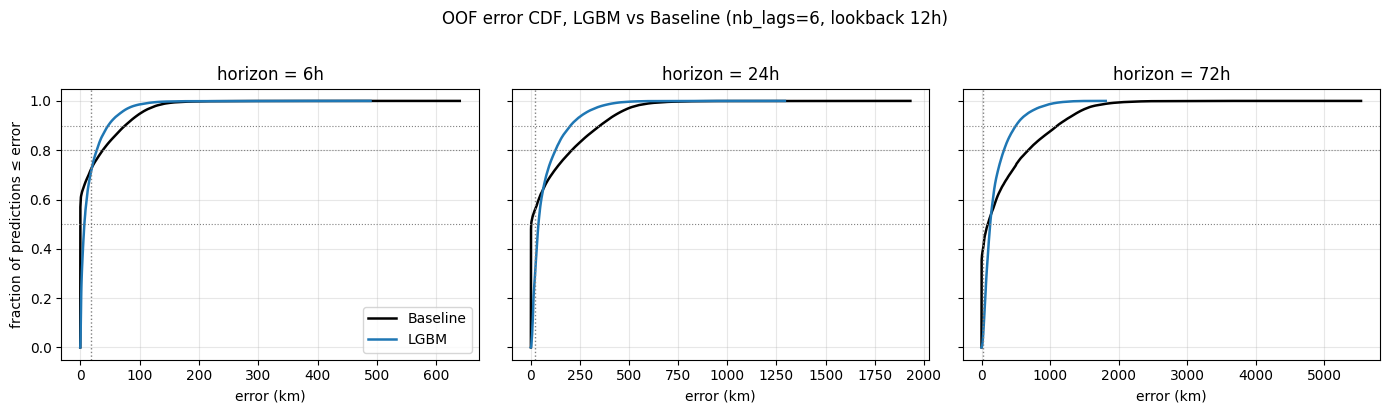

In [18]:
# --- Graph 4: OOF error CDF, LGBM (nb_lags=6) vs Baseline, lookback 12h ---
# ECDF reads percentiles directly (R90 = intersection with y=0.90) and shows the tail.
CDF_HORIZONS = [6, 24, 72]
NM10_KM = 10 * 1.852  # IAMSAR default search radius, 10 NM

fig, axes = plt.subplots(1, len(CDF_HORIZONS), figsize=(14, 4), sharey=True)
for ax, h in zip(axes, CDF_HORIZONS):
    sub = oof_ref_12h[oof_ref_12h["h"] == h * 60]
    for model_name, color in [("Baseline", "black"), ("LGBM", "C0")]:
        errors = np.sort(sub.loc[sub["model_name"] == model_name, "error_km"].values)
        cdf = np.arange(1, len(errors) + 1) / len(errors)
        ax.plot(errors, cdf, color=color, linewidth=1.8, label=model_name)
    ax.axvline(NM10_KM, color="gray", linestyle=":", linewidth=1)
    for q in (0.5, 0.8, 0.9):
        ax.axhline(q, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(f"horizon = {h}h")
    ax.set_xlabel("error (km)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("fraction of predictions ≤ error")
axes[0].legend()
fig.suptitle("OOF error CDF, LGBM vs Baseline (nb_lags=6, lookback 12h)", y=1.02)
plt.tight_layout()
plt.show()


In [35]:
(oof_ref_12h[oof_ref_12h["h"] == 4320]
 .groupby("model_name")["error_km"]
 .quantile([0.95, 0.99, 0.999, 1.0]))

model_name       
Baseline    0.950    1384.446137
            0.990    1857.718113
            0.999    2493.429359
            1.000    5538.419091
LGBM        0.950     678.235296
            0.990    1042.144860
            0.999    1372.883285
            1.000    1812.793025
Name: error_km, dtype: float64

### CDF / tail (72h panel + quantile table)

- Low-error mass: near 0 the baseline CDF rises faster (curve to the left of LGBM). Baseline still has more very-small residuals; LGBM is slightly worse on that lower part of the distribution.
- Crossover: the percentile where LGBM becomes better than the baseline moves down with horizon (~0.7 at 6h → ~0.6 at 24h → ~0.5 at 72h). Longer h means LGBM is better on a larger share of the residual mass, not only further in the tail.
- Tail: LGBM’s right tail is much thinner. At 72h it is below baseline at every high percentile (p95 678 vs 1384 km, p99 1042 vs 1858, p99.9 1373 vs 2493, max 1813 vs 5538). That matches the R90/R95 gap in the table above.


## 4. Lookback spot check (3h)


In [19]:
lookback = 3
horizon_grid_hours = [2, 6, 8, 10, 12, 24, 48, 72]
candidates_lag = [2, 6, 18]
horizon_grid_minutes = [h * 60 for h in horizon_grid_hours]
FORCE_RECOMPUTE = False  # set True to refit even if cached output exists

out_dir = Path("outputs")
summary_path_3h = out_dir / "lgbm_summary_3h.csv"

if not FORCE_RECOMPUTE and summary_path_3h.exists():
    print("Cached 3h summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_3h = pd.read_csv(summary_path_3h)
else:
    # baseline does not depend on nb_lags; only ask for it once, at nb_lags == LAG_REF.
    # Aggregate inside the loop instead of stacking full per-row oof_df across all
    # nb_lags; the 3h sweep has no CDF, so no per-row detail needs to be kept at all.
    summary_parts_3h = []

    for lag in candidates_lag:
        print(f"testing lag {lag}")

        d = create_lag_features(df=df_trainval, nb_lags=lag, lookback_minutes=lookback * 60)
        d = create_heading_features(df=d)
        d = create_target(df=d, horizon_grid_minutes=horizon_grid_minutes)

        oof_df, _ = run_crossval(
            df=d, model=lgbm_model, model_name="LGBM",
            lookback_minutes=lookback * 60, with_baseline=(lag == LAG_REF),
        )

        summary_lag_3h = compute_metrics(oof_df)
        summary_lag_3h["nb_lags"] = lag
        summary_parts_3h.append(summary_lag_3h)

    summary_3h = pd.concat(summary_parts_3h, ignore_index=True)
    summary_3h["horizon_hours"] = summary_3h["h"] / 60

    del d, oof_df
    _ = gc.collect()


testing lag 2
testing lag 6
testing lag 18


15941

In [20]:
out_dir.mkdir(parents=True, exist_ok=True)
summary_3h.to_csv(summary_path_3h, index=False)


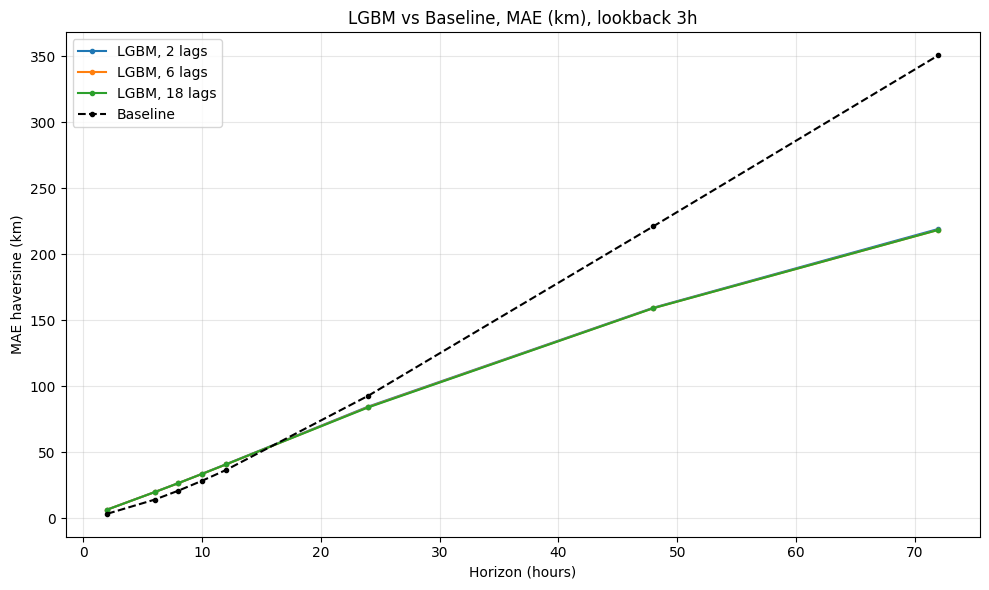

In [21]:
# --- Graph 1: MAE (km) vs horizon ---
fig, ax = plt.subplots(figsize=(10, 6))

lgbm_df = summary_3h[summary_3h["model_name"] == "LGBM"]
for nb_lags_i in sorted(lgbm_df["nb_lags"].unique()):
    subset = lgbm_df[lgbm_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    ax.plot(subset["horizon_hours"], subset["mae_mean"], marker="o", markersize=3,
            linestyle="-", label=f"LGBM, {nb_lags_i} lags")

baseline_df = summary_3h[summary_3h["model_name"] == "Baseline"].sort_values("horizon_hours")
ax.plot(baseline_df["horizon_hours"], baseline_df["mae_mean"], marker="o", markersize=3,
        linestyle="--", color="black", label="Baseline")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("LGBM vs Baseline, MAE (km), lookback 3h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

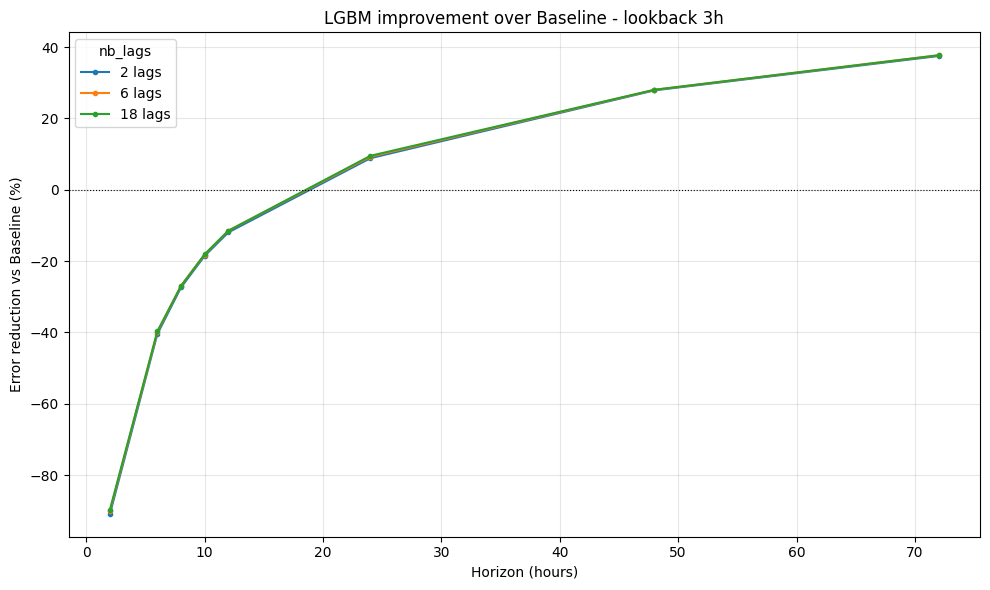

In [22]:
# --- Graph 2: improvement over Baseline (%) ---
baseline_lookup = baseline_df.set_index("horizon_hours")["mae_mean"]

fig, ax = plt.subplots(figsize=(10, 6))
for nb_lags_i in sorted(lgbm_df["nb_lags"].unique()):
    subset = lgbm_df[lgbm_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    mae_baseline = subset["horizon_hours"].map(baseline_lookup)
    improvement_pct = (mae_baseline - subset["mae_mean"]) / mae_baseline * 100
    ax.plot(subset["horizon_hours"], improvement_pct, marker="o", markersize=3,
            linestyle="-", label=f"{nb_lags_i} lags")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Error reduction vs Baseline (%)")
ax.set_title("LGBM improvement over Baseline - lookback 3h")
ax.legend(title="nb_lags")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

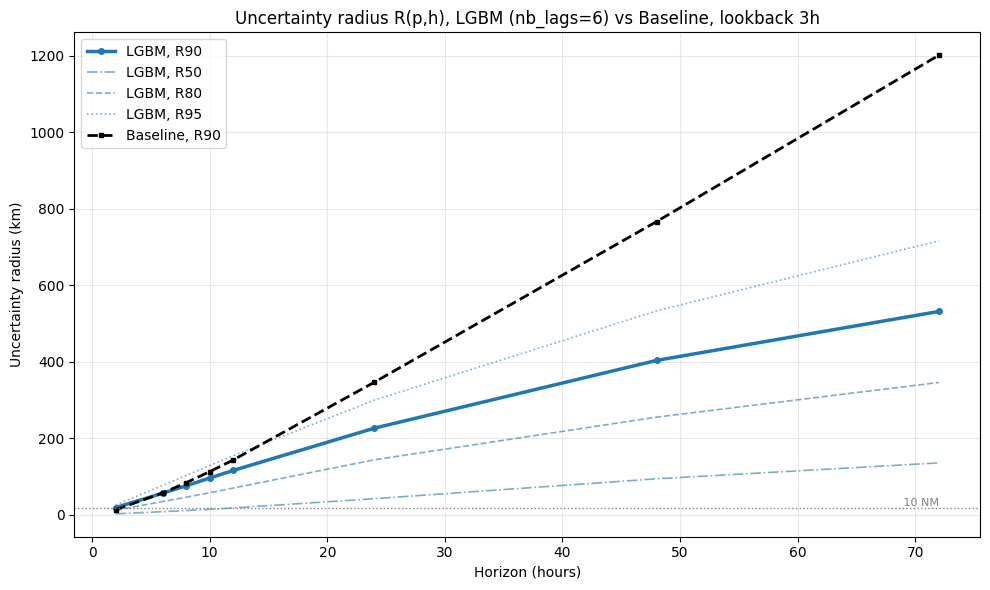

In [23]:
# --- Graph 3: uncertainty radius R(p,h), LGBM (nb_lags=6) vs Baseline, lookback 3h ---
NM_TO_KM = 1.852

lgbm_r = summary_3h[
    (summary_3h["model_name"] == "LGBM") & (summary_3h["nb_lags"] == LAG_REF)
].sort_values("horizon_hours")

baseline_r = summary_3h[summary_3h["model_name"] == "Baseline"].sort_values("horizon_hours")

fig, ax = plt.subplots(figsize=(10, 6))

# LGBM, R90 bold; R50 / R80 / R95 lighter
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r90_km"], color="C0", linewidth=2.5,
        marker="o", markersize=4, label="LGBM, R90")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r50_km"], color="C0", linewidth=1.2,
        linestyle="-.", alpha=0.6, label="LGBM, R50")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r80_km"], color="C0", linewidth=1.2,
        linestyle="--", alpha=0.6, label="LGBM, R80")
ax.plot(lgbm_r["horizon_hours"], lgbm_r["r95_km"], color="C0", linewidth=1.2,
        linestyle=":", alpha=0.6, label="LGBM, R95")

# Baseline, R90 only, dashed black
ax.plot(baseline_r["horizon_hours"], baseline_r["r90_km"], color="black", linewidth=2,
        linestyle="--", marker="s", markersize=3, label="Baseline, R90")

# SAR reference line (10 NM)
ax.axhline(10 * NM_TO_KM, color="gray", linestyle=":", linewidth=1)
ax.text(lgbm_r["horizon_hours"].max(), 10 * NM_TO_KM, " 10 NM", va="bottom", ha="right", fontsize=8, color="gray")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title(f"Uncertainty radius R(p,h), LGBM (nb_lags={LAG_REF}) vs Baseline, lookback 3h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Table: horizon × R50/R80/R90/R95 (km), LGBM (nb_lags=6) vs Baseline, lookback 3h
radius_tbl_3h = (
    summary_3h[
        (
            ((summary_3h["model_name"] == "LGBM") & (summary_3h["nb_lags"] == LAG_REF))
            | (summary_3h["model_name"] == "Baseline")
        )
    ]
    .pivot_table(
        index="horizon_hours",
        columns="model_name",
        values=["r50_km", "r80_km", "r90_km", "r95_km"],
        aggfunc="first",
    )
    .sort_index()
    .round(2)
)
radius_tbl_3h = radius_tbl_3h.reindex(
    columns=pd.MultiIndex.from_product(
        [["r50_km", "r80_km", "r90_km", "r95_km"], ["Baseline", "LGBM"]]
    )
)
radius_tbl_3h


r50_km           r80_km           r90_km           r95_km  \
              Baseline    LGBM Baseline    LGBM Baseline    LGBM Baseline   
horizon_hours                                                               
2.0               0.00    2.67     2.99   11.86    13.14   18.89    24.20   
6.0               0.01    8.19    20.77   34.79    57.08   56.42    85.88   
8.0               0.01   11.18    34.84   45.92    83.87   75.89   120.85   
10.0              0.02   14.49    50.26   57.79   112.88   96.08   157.56   
12.0              0.03   17.96    67.99   69.97   143.41  116.01   196.21   
24.0              0.46   42.18   195.79  143.88   346.71  226.56   441.06   
48.0             29.16   94.17   476.10  255.38   766.75  403.74   947.43   
72.0             66.94  135.77   720.93  346.10  1201.66  531.80  1466.13   

                       
                 LGBM  
horizon_hours          
2.0             25.58  
6.0             76.84  
8.0            102.76  
10.0           128.92  
12.0           154.65  
24.0           299.90  
48.0           533.28  
72.0           716.54

### 4.1 Conclusion

- At a **3h** lookback LGBM is worse than at **12h** at every horizon (e.g. R90 at 72h **532** vs **503** km), which confirms the 12h choice from NB03 for the learned model.


## 5. Hyperparameter check

Small grid search to assess whether tuning would be a useful lever. Several searches were run in sequence, each time narrowing the ranges; the `param_grid` in the cell below is only the **last** of those. Best params and score are frozen in §5.1 — by default the search is skipped (`FORCE_RECOMPUTE = False`).


In [29]:
# Tuning probe: single horizon (24h), 12h lookback, 6 lags.
# Internal model-selection only: scoring in velocity space (vx, vy) with neg MAE.
# best_score_ is in deg/min, not km — ranking only, not an operational error.
# param_grid below is the LAST narrowed grid of several successive searches.
from types import SimpleNamespace

H_PROBE_MIN = 24 * 60
LOOKBACK_PROBE = 12
NB_LAGS_PROBE = LAG_REF
FORCE_RECOMPUTE = False  # set True to rerun GridSearchCV

# Frozen from the last GridSearchCV run (see §5.1)
FROZEN_BEST_PARAMS = {
    "estimator__learning_rate": 0.005,
    "estimator__min_child_samples": 900,
    "estimator__n_estimators": 800,
    "estimator__num_leaves": 127,
}
FROZEN_BEST_SCORE = -0.0003134896928430887  # neg MAE on vx, vy (deg/min)

if not FORCE_RECOMPUTE:
    print("Skipping GridSearchCV (set FORCE_RECOMPUTE=True to rerun). Using frozen best_params / best_score from §5.1.")
    search = SimpleNamespace(best_params_=FROZEN_BEST_PARAMS, best_score_=FROZEN_BEST_SCORE)
    print("best_params:", search.best_params_)
    print("best_score (neg MAE on vx, vy, deg/min, internal ranking only):", search.best_score_)
else:
    df_probe = create_lag_features(df=df_trainval, nb_lags=NB_LAGS_PROBE, lookback_minutes=LOOKBACK_PROBE * 60)
    df_probe = create_heading_features(df=df_probe)
    df_probe = create_target(df=df_probe, horizon_grid_minutes=[H_PROBE_MIN])

    feature_cols = [c for c in df_probe.columns if c.startswith(("LAT_lag", "LON_lag"))]
    feature_cols += ["SOG", "Heading_sin", "Heading_cos", "Length", "Width", "Draft", "h"]

    X_probe = df_probe[feature_cols]
    y_probe = df_probe[["vx", "vy"]]
    groups_probe = df_probe["MMSI"]

    gkf_grid = GroupKFold(n_splits=3)
    lgbm_grid = MultiOutputRegressor(
        LGBMRegressor(n_jobs=1, verbose=-1, random_state=settings.random_seed)
    )
    param_grid = {
        "estimator__learning_rate": [0.003, 0.005, 0.01],
        "estimator__n_estimators": [800, 1000, 1200],
        "estimator__num_leaves": [127],
        "estimator__min_child_samples": [500, 700, 900],
    }

    search = GridSearchCV(
        lgbm_grid,
        param_grid,
        scoring="neg_mean_absolute_error",
        cv=gkf_grid,
        n_jobs=-1,
    )
    search.fit(X_probe, y_probe, groups=groups_probe)

    print("best_params:", search.best_params_)
    print("best_score (neg MAE on vx, vy, deg/min, internal ranking only):", search.best_score_)

    del df_probe
    _ = gc.collect()


best_params: {'estimator__learning_rate': 0.005, 'estimator__min_child_samples': 900, 'estimator__n_estimators': 800, 'estimator__num_leaves': 127}
best_score (neg MAE on vx, vy, deg/min, internal ranking only): -0.0003134896928430887


115

In [30]:
#

base_24h = oof_ref_12h[(oof_ref_12h["model_name"] == "LGBM") & (oof_ref_12h["h"] == 1440)]

base_mae_vx = (base_24h["vx_pred"] - base_24h["vx_true"]).abs().mean()
base_mae_vy = (base_24h["vy_pred"] - base_24h["vy_true"]).abs().mean()
base_mae_uniform = (base_mae_vx + base_mae_vy) / 2  # matches sklearn's default multioutput="uniform_average"

print(f"base (untuned) LGBM, MAE vx/vy deg/min, 24h: {base_mae_uniform:.6f}")
print(f"tuned (best_params), same units:            {-search.best_score_:.6f}")
print(f"relative change: {(base_mae_uniform - (-search.best_score_)) / base_mae_uniform * 100:.1f}%")

base (untuned) LGBM, MAE vx/vy deg/min, 24h: 0.000321
tuned (best_params), same units:            0.000313
relative change: 2.4%


### 5.1 Grid search results

Probe: lookback 12h, nb_lags=6, horizon 24h. Values frozen from the last GridSearchCV run (matches the printed output above when the search was executed). The `param_grid` in the code cell is only that last narrowed grid, not the full sequence of earlier searches.

- `search.best_score_` = **-0.0003134896928430887** → MAE ≈ **0.000313 deg/min** (scorer is `greater_is_better=False`)
- `search.best_params_`:
  - `learning_rate` = 0.005
  - `n_estimators` = 800
  - `num_leaves` = 127
  - `min_child_samples` = 900


### 5.2 Conclusion

Best setting (lookback 12h, 6 lags, horizon 24h):
`{learning_rate=0.005, n_estimators=800, num_leaves=127, min_child_samples=900}` → **MAE ≈ 0.000313 deg/min**.

vs untuned LGBM (**0.000321 deg/min**): about **−2.4%**. This is only modest and further refining is unlikely to move the needle.

Several grid searches were run, progressively narrowing the ranges. What is shown above is the last one, so the full search space is not all visible. Tuning gave about 2.4 percent. The conclusion is that tuning is not the lever: the ceiling is informational (what the base features can express).


## 6. Results and interpretation




### 6.1 Comparison MAE

MAE of the three models at the shared operating point: lookback 12h, 6 lags.


In [31]:
out_dir = Path("outputs")
ridge_summary = pd.read_csv(out_dir / "ridge_summary_12h.csv")   # from NB04
lgbm_summary = pd.read_csv(out_dir / "lgbm_summary_12h.csv")     # from this notebook
# LAG_REF already set in §3.1; keep a local fallback if §6 is run alone
LAG_REF = globals().get("LAG_REF", 6)

baseline_mae = (lgbm_summary[lgbm_summary["model_name"] == "Baseline"]
                .set_index("horizon_hours")["mae_mean"].rename("baseline"))
ridge_mae = (ridge_summary[(ridge_summary["model_name"] == "Ridge") & (ridge_summary["nb_lags"] == LAG_REF)]
             .set_index("horizon_hours")["mae_mean"].rename("ridge"))
lgbm_mae = (lgbm_summary[(lgbm_summary["model_name"] == "LGBM") & (lgbm_summary["nb_lags"] == LAG_REF)]
            .set_index("horizon_hours")["mae_mean"].rename("lgbm"))

comparison_mae = pd.concat([baseline_mae, ridge_mae, lgbm_mae], axis=1).sort_index().round(2)
comparison_mae


,baseline,ridge,lgbm
horizon_hours,,,
2.0,5.95,6.02,5.61
4.0,12.49,12.35,11.13
6.0,19.61,18.99,16.84
8.0,27.22,25.92,22.82
10.0,35.25,33.11,28.99
12.0,43.63,40.53,35.39
24.0,98.81,88.51,76.14
48.0,219.94,191.73,148.49
72.0,338.56,295.31,208.51


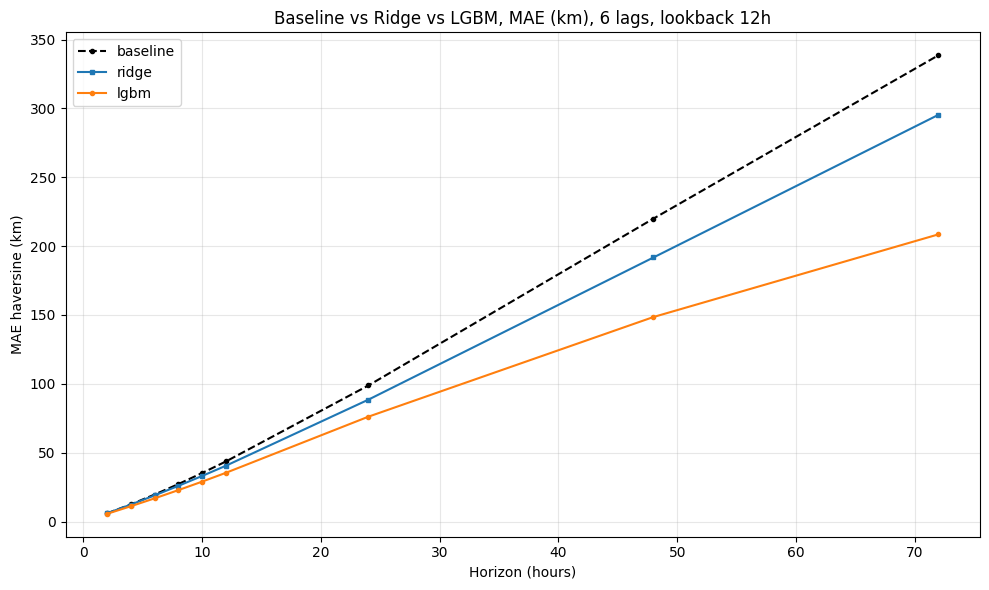

In [32]:
# MAE plot
fig, ax = plt.subplots(figsize=(10, 6))
styles = {"baseline": ("--", "black", "o"), "ridge": ("-", "C0", "s"), "lgbm": ("-", "C1", "o")}
for col, (ls, c, m) in styles.items():
    ax.plot(comparison_mae.index, comparison_mae[col], linestyle=ls, color=c, marker=m, markersize=3, label=col)
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("Baseline vs Ridge vs LGBM, MAE (km), 6 lags, lookback 12h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


LGBM has the lowest MAE at every horizon, including the shortest. Ridge never leads. The gap over the baseline widens with the horizon, from about 6 percent at 2h to about 38 percent at 72h. Detailed reading in 6.3.


### 6.2 Comparison uncertainty radius across models

Same operating point as 6.1 (lookback 12h, nb_lags = 6). R50 is the median residual, R90 the tail.


In [33]:
# R50 / R90 comparison
def _radius(df, model_name, col, label):
    q = df["model_name"] == model_name
    if model_name != "Baseline":
        q = q & (df["nb_lags"] == LAG_REF)
    return df.loc[q].set_index("horizon_hours")[col].rename(label)

radius_comparison = pd.concat([
    _radius(lgbm_summary, "Baseline", "r50_km", "baseline_r50"),
    _radius(ridge_summary, "Ridge", "r50_km", "ridge_r50"),
    _radius(lgbm_summary, "LGBM", "r50_km", "lgbm_r50"),
    _radius(lgbm_summary, "Baseline", "r90_km", "baseline_r90"),
    _radius(ridge_summary, "Ridge", "r90_km", "ridge_r90"),
    _radius(lgbm_summary, "LGBM", "r90_km", "lgbm_r90"),
], axis=1).sort_index().round(2)
radius_comparison


,baseline_r50,ridge_r50,lgbm_r50,baseline_r90,ridge_r90,lgbm_r90
horizon_hours,,,,,,
2.0,0.01,2.63,2.26,23.43,16.12,15.96
4.0,0.01,5.35,4.55,48.64,33.03,31.43
6.0,0.03,8.14,6.96,75.51,50.61,47.10
8.0,0.05,11.02,9.72,103.96,69.21,63.47
10.0,0.09,14.00,12.73,133.35,89.04,80.44
12.0,0.14,17.07,15.83,163.40,110.09,98.50
24.0,1.72,36.96,38.42,352.13,247.30,201.50
48.0,40.24,84.92,85.48,728.72,531.59,374.04
72.0,90.88,139.00,126.60,1107.55,816.88,502.85


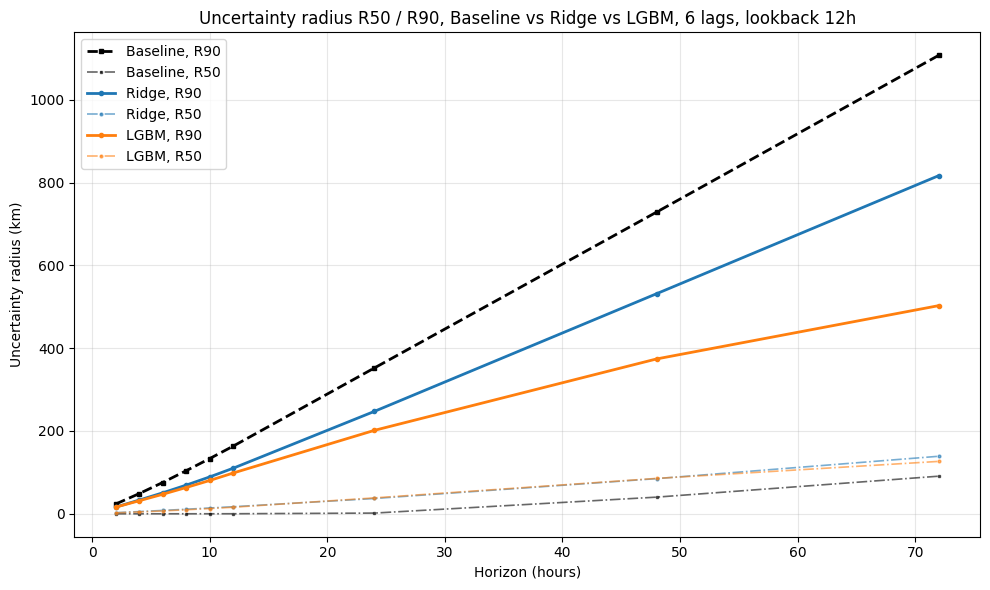

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
radius_styles = {
    "baseline_r90": {"linestyle": "--", "color": "black", "linewidth": 2.0, "marker": "s", "markersize": 3, "label": "Baseline, R90"},
    "baseline_r50": {"linestyle": "-.", "color": "black", "linewidth": 1.2, "alpha": 0.6, "marker": "s", "markersize": 2, "label": "Baseline, R50"},
    "ridge_r90": {"linestyle": "-", "color": "C0", "linewidth": 2.0, "marker": "o", "markersize": 3, "label": "Ridge, R90"},
    "ridge_r50": {"linestyle": "-.", "color": "C0", "linewidth": 1.2, "alpha": 0.6, "marker": "o", "markersize": 2, "label": "Ridge, R50"},
    "lgbm_r90": {"linestyle": "-", "color": "C1", "linewidth": 2.0, "marker": "o", "markersize": 3, "label": "LGBM, R90"},
    "lgbm_r50": {"linestyle": "-.", "color": "C1", "linewidth": 1.2, "alpha": 0.6, "marker": "o", "markersize": 2, "label": "LGBM, R50"},
}
for col, style in radius_styles.items():
    ax.plot(radius_comparison.index, radius_comparison[col], **style)
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title("Uncertainty radius R50 / R90, Baseline vs Ridge vs LGBM, 6 lags, lookback 12h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


On R90, LGBM gives the smallest radius at every horizon, and the baseline is the largest. On R50 the baseline is still the lowest. Ridge does not provide an advantage in any region of the distribution. 


### 6.3 Interpretation


#### 6.3.1 What the three models show

On MAE, LGBM is best at every horizon, including the shortest, and pulls away as the horizon grows (72h: baseline 339, Ridge 295, LGBM 209 km). The non-linear model has lower error than the linear one across the whole range.

This means that there is usable non-linear information at every horizon. But it becomes more valuable as horizon increases. This is consistent with the working hypothesis that increasing the horizon increases the share of composite tracks mixing different regimes (stationary, rectilinear, manoeuvring), making them harder to predict.

The uncertainty radius provides additional information.

- On the median (R50), the baseline is better: R50 stays near 0 up to 24h. For half of the tracks (under the baseline's own error distribution), constant-velocity extrapolation is essentially exact.
- On the tail (R90), the baseline is the worst of the three at every horizon (R90 at 8h: baseline 104, Ridge 69, LGBM 63 km; at 72h: baseline 1108, Ridge 817, LGBM 503 km).

So the same baseline is both the best and the worst predictor, depending on whether we look at the typical case or the hard residual mass.

#### 6.3.2 Why the baseline has a great median and a bad tail

Owing to how the baseline is computed (geometrical extrapolation) we can hypothesize that the low-error tracks in the baseline data are linear tracks where the vessels keep going straight between present and horizon. Here, the baseline is undisputably better, by construction. In high sea, this may represent a large part of tracks, especially at lower horizon (shorter tracks).

Its error distribution is therefore a sharp spike near 0 with a very heavy tail.

The learned models do the opposite. They are a bit worse on the easy majority (Ridge and LGBM R50 are higher than the baseline's), because a learned model does not stick exactly to the straight line — a plausible reading is that it hedges the possibility of a turn. That same effect keeps the tail under control (LGBM R90 approaches half the baseline's by 48h and falls below half by 72h). The value of the learned model is not better accuracy everywhere, but better accuracy on the upper part of the error distribution.

The CDF (Graph 4) shows this directly: the baseline curve rises fastest near 0 (best median) then flattens into a long tail (worst R90), while the LGBM curve rises more gently but reaches 1.0 much sooner (lighter tail). The point where the two curves cross is the percentile where the better model flips. Below it the baseline wins, above it LGBM wins. That crossover also moves down with horizon (see §3.2.2), so LGBM covers a larger share of residual mass as h grows.

#### 6.3.3 Operational choice: when the model earns its cost

R90 is a better operational reference than R50, because a search area has to contain the vessel with high confidence.

The question is whether the model's advantage is worth its extra cost over a trivial baseline. We answer it visually, by watching where the baseline and LGBM R90 curves start to diverge.

- At 2h the LGBM R90 gap over the baseline is already present (16 vs 23 km): LGBM sits near / just under the 10 NM reference, while the baseline is already a bit above it. The baseline is still simple and close enough that the operational difference is small.
- From about 4h the gap opens fast (17 km at 4h, 40 at 8h, 151 at 24h) and the LGBM area reduction keeps growing, from about 64 percent at 12h to about 79 percent at 72h. This is where the model adds value worth the computation cost.

So the baseline is defensible only at very short horizons, where absolute errors are small and simplicity wins. Beyond that LGBM gives a clearly tighter search area, and its advantage grows with the horizon, which is where the search area is largest and the reduction matters most.

Reading the MAE alone would place the switch later, around 8h, because the mean is dominated by the bulk of easy cases and is less sensitive than the 90th percentile to the hard residual mass that drives the search area.

#### 6.3.4 Why we don't route on trajectory type, and why we drop Ridge

A vessel going straight during the lookback doesn't indicate an easy-to-predict track that could be routed to a baseline model. The vessel could keep going straight (in which case the baseline would be appropriate) or turn sharply during the horizon time window, in which case LGBM would probably be better. In later notebooks, we'll explore whether there is a way to anticipate this.

At short horizon, where Ridge is closest to LGBM, the baseline is already good enough and simpler. After that, LGBM dominates. So we'll drop the Ridge model from here onward.


## 7. Conclusion

- **Retained model:** single **LGBM**, lowest MAE at every horizon, tail controlled on R90.
- The baseline keeps the lower R50 on the straight, easy majority; the operational switch to LGBM is read on **R90 around 4h**, earlier than the MAE view.
- Ridge dropped. Whether easy tracks can be routed to the baseline is left **open** and tested later.
- **Next:** feature engineering (NB06).
